In [74]:
from pathlib import Path

GTFS_PATH = Path.cwd().parent / "data" / "raw" / "gtfs_vmt" / "extracted"

print(f"GTFS-Dateien von {GTFS_PATH}")
for file in GTFS_PATH.glob("*.txt"):
    print(f"{file.name}")

GTFS-Dateien von /Users/leon/Projects/transIT/data/raw/gtfs_vmt/extracted
transfers.txt
agency.txt
calendar_dates.txt
stop_times.txt
frequencies.txt
shapes.txt
trips.txt
feed_info.txt
stops.txt
calendar.txt
routes.txt


In [75]:
#Wichtigsten Dateien inkl. Dimensionen laden
import pandas as pd

routes=pd.read_csv(GTFS_PATH/"routes.txt") #-->  Linien (Route=Linie)
trips=pd.read_csv(GTFS_PATH/"trips.txt") #--> Linienrouten (trip=FAhrt)
stops=pd.read_csv(GTFS_PATH/"stops.txt") #--> Hst
agency=pd.read_csv(GTFS_PATH/"agency.txt") #--> VU
stop_times = pd.read_csv(GTFS_PATH/"stop_times.txt") #-->Haltezeiten

print(f"Routes {routes.shape}")
print(f"{routes.dtypes} \n")

print(f"Trips {trips.shape}")
print(f"{trips.dtypes} \n")

print(f"Stops {stops.shape}")
print(f"{stops.dtypes} \n")

print(f"Agency {agency.shape}")
print(f"{agency.dtypes} \n")

print(f"Stop Times {stop_times.shape}")
print(f"{stop_times.dtypes} \n")



"""
display(routes.head())
display(trips.head())
display(stops.head())
display(agency.head())
display(stop_times())
"""


/var/folders/g5/115sqwx15x7cmsl32yg56d_80000gn/T/ipykernel_1533/323502427.py:8: DtypeWarning: Columns (0: stop_headsign) have mixed types. Specify dtype option on import or set low_memory=False.
  stop_times = pd.read_csv(GTFS_PATH/"stop_times.txt") #-->Haltezeiten


Routes (857, 8)
route_id                str
agency_id             int64
route_short_name        str
route_long_name     float64
route_type            int64
route_color             str
route_text_color        str
route_desc          float64
dtype: object 

Trips (115512, 10)
route_id                     str
service_id                 int64
trip_id                    int64
trip_headsign                str
trip_short_name          float64
direction_id               int64
block_id                 float64
shape_id                 float64
wheelchair_accessible      int64
bikes_allowed              int64
dtype: object 

Stops (13169, 10)
stop_id                    str
stop_code              float64
stop_name                  str
stop_desc              float64
stop_lat               float64
stop_lon               float64
location_type            int64
parent_station         float64
wheelchair_boarding      int64
platform_code              str
dtype: object 

Agency (44, 6)
agency_id           

'\ndisplay(routes.head())\ndisplay(trips.head())\ndisplay(stops.head())\ndisplay(agency.head())\ndisplay(stop_times())\n'

In [76]:
#Alle VU in ganz Thüringen
agency[["agency_id", "agency_name"]].sort_values("agency_name")

,agency_id,agency_name
29,176,Abellio Rail Mitteldeutschland GmbH
41,237,Busbetrieb Piehler GmbH & Co. KG
4,78,Deutsche Bahn
21,131,EW Bus GmbH
28,172,Erfurter Bahn
27,171,Erfurter Bahn
16,119,Erfurter Verkehrsbetriebe AG (EVAG)
34,211,Firma Schieck
9,111,GVB Verkehrs- und Betriebsgesellschaft Gera mb...
26,166,Harzer Schmalspurbahnen GmbH


In [77]:
#Merkmale ausgeben
print("Routes:", routes.columns.tolist())
print("Trips:", trips.columns.tolist())
print("Stops:", stops.columns.tolist())
print("Agency:", agency.columns.tolist())
print("Stop times:", stop_times.columns.tolist())

Routes: ['route_id', 'agency_id', 'route_short_name', 'route_long_name', 'route_type', 'route_color', 'route_text_color', 'route_desc']
Trips: ['route_id', 'service_id', 'trip_id', 'trip_headsign', 'trip_short_name', 'direction_id', 'block_id', 'shape_id', 'wheelchair_accessible', 'bikes_allowed']
Stops: ['stop_id', 'stop_code', 'stop_name', 'stop_desc', 'stop_lat', 'stop_lon', 'location_type', 'parent_station', 'wheelchair_boarding', 'platform_code']
Agency: ['agency_id', 'agency_name', 'agency_url', 'agency_timezone', 'agency_lang', 'agency_phone']
Stop times: ['trip_id', 'stop_id', 'stop_sequence', 'pickup_type', 'drop_off_type', 'stop_headsign', 'arrival_time', 'departure_time']


In [78]:
#Schlüsselkonsistenzen

print("Agency IDs:", agency["agency_id"].nunique(), "/", len(agency))
print("Route IDs:", routes["route_id"].nunique(), "/", len(routes))
print("Trip IDs:", trips["trip_id"].nunique(), "/", len(trips))
print("Stop IDs:", stops["stop_id"].nunique(), "/", len(stops))

Agency IDs: 44 / 44
Route IDs: 857 / 857
Trip IDs: 115512 / 115512
Stop IDs: 13169 / 13169


In [79]:

display(stop_times.head())

,trip_id,stop_id,stop_sequence,pickup_type,drop_off_type,stop_headsign,arrival_time,departure_time
0,40063150,de:16063:163004::16300402,0,0,0,NaN,9:30:00,9:30:00
1,40063150,de:16063:163013::16301300,1,0,0,NaN,9:32:00,9:32:00
2,40063150,de:16063:163005::16300500,2,0,0,NaN,9:33:00,9:33:00
3,40063150,de:16063:163011::16301100,3,0,0,NaN,9:35:00,9:35:00
4,40063150,de:16063:1700754::170075400,4,0,0,NaN,9:38:00,9:38:00


In [80]:
#Test auf Foreignkeyabhängigkeiten

#routes -> agency
invalid_route_agencies = routes[~routes["agency_id"].isin(agency["agency_id"])]
print("Routes mit unbekannter agency_id:",len(invalid_route_agencies))
print("Unbekannte trip_id:",(~stop_times["trip_id"].isin(trips["trip_id"])).sum())
print("Unbekannte stop_id:",(~stop_times["stop_id"].isin(stops["stop_id"])).sum())

#trips -> routes
invalid_trip_routes = trips[~trips["route_id"].isin(routes["route_id"])]
print("Trips mit unbekannter route_id:",len(invalid_trip_routes))

#stop_times -> stops
print("Unbekannte trip_id:",(~stop_times["trip_id"].isin(trips["trip_id"])).sum())
print("Unbekannte stop_id:",(~stop_times["stop_id"].isin(stops["stop_id"])).sum())

Routes mit unbekannter agency_id: 0
Unbekannte trip_id: 0
Unbekannte stop_id: 0
Trips mit unbekannter route_id: 0
Unbekannte trip_id: 0
Unbekannte stop_id: 0


In [81]:
#Zeitdaten laden

#Fahrplankalender
calendar = pd.read_csv(GTFS_PATH/"calendar.txt") #1=Ja, 0=Nein
#Calendardates: Ausnahmen des Fahrplankalenders --> 1: Zusätzliche Fahrt und 2: Fahrt entfernen
calendar_dates = pd.read_csv(GTFS_PATH/"calendar_dates.txt") #1=Zusätzliche Fahrt

print(f"Calendar {calendar.shape}")
print(f"{calendar.dtypes} \n")

print(f"Calendar dates {calendar_dates.shape}")
print(f"{calendar_dates.dtypes} \n")


print("calendar:", calendar.columns.tolist())
print("Calendar dates", calendar_dates.columns.tolist()) #Service-id: Verbindung zwischen PlanFahrt und Fahrplankalender

Calendar (2273, 10)
service_id    int64
monday        int64
tuesday       int64
wednesday     int64
thursday      int64
friday        int64
saturday      int64
sunday        int64
start_date    int64
end_date      int64
dtype: object 

Calendar dates (67385, 3)
service_id        int64
date              int64
exception_type    int64
dtype: object 

calendar: ['service_id', 'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday', 'start_date', 'end_date']
Calendar dates ['service_id', 'date', 'exception_type']


In [82]:
print("Calendar:")
print("Start:", calendar["start_date"].min(), "End:", calendar["end_date"].max())

print(f"\ncalendar_dates:")
print("Datum:",calendar_dates["date"].min(), "bis", calendar_dates["date"].max())

print(f"\nAnzahl service_id:")
print("calendar:", calendar["service_id"].nunique())
print("calendar_dates:", calendar_dates["service_id"].nunique())

Calendar:
Start: 20260801 End: 20270228

calendar_dates:
Datum: 20260801 bis 20270228

Anzahl service_id:
calendar: 2273
calendar_dates: 2266


In [83]:
#Übersicht über verschiedene Fahrten-Tag-Konstellationen
calendar.head()
#print("calendar:", calendar.columns.tolist())
weekdays = ["monday", "tuesday", "wednesday", "thursday", "friday", "saturday", "sunday"]
calendar[weekdays].value_counts().reset_index(name="service_count")

,monday,tuesday,wednesday,thursday,friday,saturday,sunday,service_count
0,0,0,0,0,0,0,0,1449
1,1,1,1,1,1,0,0,202
2,1,1,1,1,1,1,1,103
3,0,0,0,0,0,1,1,96
4,0,0,0,0,0,1,0,77
5,0,0,0,0,0,0,1,54
6,1,1,1,1,1,1,0,52
7,1,1,1,1,0,0,0,39
8,0,0,0,0,1,0,0,25
9,1,1,1,1,1,0,1,15


In [84]:

calendar_dates.groupby("exception_type")["service_id"].nunique()

exception_type
1    1781
2     808
Name: service_id, dtype: int64

In [85]:
"""
example_service = calendar["service_id"].iloc[0]

print("Beispiel service_id:", example_service)

display(
    calendar[
        calendar["service_id"] == example_service
    ]
)

display(
    calendar_dates[
        calendar_dates["service_id"] == example_service
    ]
)
"""

'\nexample_service = calendar["service_id"].iloc[0]\n\nprint("Beispiel service_id:", example_service)\n\ndisplay(\n    calendar[\n        calendar["service_id"] == example_service\n    ]\n)\n\ndisplay(\n    calendar_dates[\n        calendar_dates["service_id"] == example_service\n    ]\n)\n'

In [86]:
trip_services=set(trips["service_id"])

calendar_services=set(calendar["service_id"])
calendar_date_services=set(calendar_dates["service_id"])

missing_calendar= trip_services - (calendar_services|calendar_date_services)

print("Services in trips ohne calendar/calendar_dates:",len(missing_calendar))

#-->Keine Service Id in Trips, die nicht in calendar(_dates) ist

Services in trips ohne calendar/calendar_dates: 0


In [87]:
service_patterns = (calendar[weekdays].value_counts().reset_index(name="service_count"))
service_patterns

,monday,tuesday,wednesday,thursday,friday,saturday,sunday,service_count
0,0,0,0,0,0,0,0,1449
1,1,1,1,1,1,0,0,202
2,1,1,1,1,1,1,1,103
3,0,0,0,0,0,1,1,96
4,0,0,0,0,0,1,0,77
5,0,0,0,0,0,0,1,54
6,1,1,1,1,1,1,0,52
7,1,1,1,1,0,0,0,39
8,0,0,0,0,1,0,0,25
9,1,1,1,1,1,0,1,15


### Transformation von Calendar und trips zu vollständigen Fahrplankalender vom 01.08.26 bis 28.02.27

In [88]:
date_range = pd.date_range(
    start=pd.to_datetime(calendar["start_date"].astype(str), format="%Y%m%d").min(),
    end=pd.to_datetime(calendar["end_date"].astype(str), format="%Y%m%d").max(),
)

print(f"Datumsbereich geht von", date_range.min(), "bis", date_range.max())

Datumsbereich geht von 2026-08-01 00:00:00 bis 2027-02-28 00:00:00


In [89]:
calendar["start_date"]=pd.to_datetime(calendar["start_date"].astype(str), format="%Y%m%d")
calendar["end_date"]=pd.to_datetime(calendar["end_date"].astype(str), format="%Y%m%d")
calendar_dates["date"]=pd.to_datetime(calendar_dates["date"].astype(str), format="%Y%m%d")

In [90]:
calendar["start_date"]

0      2026-08-01
1      2026-08-01
2      2026-08-01
3      2026-08-01
4      2026-08-01
          ...    
2268   2026-08-01
2269   2026-08-01
2270   2026-08-01
2271   2026-08-01
2272   2026-08-01
Name: start_date, Length: 2273, dtype: datetime64[us]

In [91]:
def map_service_With_concrete_date(service, date):
    if date > service["end_date"] or date < service["start_date"]:
        return

    weekday = date.weekday()

    map_weekday = {
        0: "monday",
        1: "tuesday",
        2: "wednesday",
        3: "thursday",
        4: "friday",
        5: "saturday",
        6: "sunday",
    }

    return service[map_weekday[weekday]] == 1

In [92]:
service_calendar = []

for i, service in calendar.iterrows():
    for date in date_range:
        if date > service["end_date"] or date < service["start_date"]:
            continue
         
        weekday = date.weekday()
        
        map_weekday = {
            0: "monday",
            1: "tuesday",
            2: "wednesday",
            3: "thursday",
            4: "friday",
            5: "saturday",
            6: "sunday",
        }

        if service[map_weekday[weekday]] ==1:
            service_calendar.append({
                "service_id": service["service_id"],
                "date": date
            })

service_calendar = pd.DataFrame(service_calendar)

display(service_calendar.head())



,service_id,date
0,6,2026-08-03
1,6,2026-08-04
2,6,2026-08-05
3,6,2026-08-06
4,6,2026-08-07


In [93]:
#Calendar_dates bereinigen

add_services = calendar_dates[calendar_dates["exception_type"] ==1][["service_id", "date"]]
rem_services = calendar_dates[calendar_dates["exception_type"] ==2][["service_id", "date"]]

print(f"Zusätzliche Fahren:", len(add_services), "Enfternte Fahrten:", len(rem_services))

Zusätzliche Fahren: 34685 Enfternte Fahrten: 32700


In [97]:
service_calendar = service_calendar.merge(
    rem_services.assign(remove=True),
    on=["service_id", "date"],
    how="left"
)

service_calendar=service_calendar[service_calendar["remove"] != True].drop(columns="remove")

service_calender = pd.concat([service_calendar, add_services], ignore_index=True)
service_calendar = (service_calendar.drop_duplicates(["service_id", "date"]).sort_values(["date", "service_id"]).reset_index(drop=True))

In [98]:
display(service_calendar.head(20))

,service_id,date
0,7,2026-08-01
1,84,2026-08-01
2,86,2026-08-01
3,96,2026-08-01
4,97,2026-08-01
5,113,2026-08-01
6,126,2026-08-01
7,127,2026-08-01
8,150,2026-08-01
9,181,2026-08-01


In [101]:
daily_services = (service_calender.groupby("date").size().reset_index(name="active_services"))

,date,active_services
0,2026-08-01,427
1,2026-08-02,360
2,2026-08-03,576
3,2026-08-04,573
4,2026-08-05,553
5,2026-08-06,546
6,2026-08-07,543
7,2026-08-08,415
8,2026-08-09,353
9,2026-08-10,573


Matplotlib is building the font cache; this may take a moment.


<Axes: title={'center': 'Anzahl Servicefahrten je Datum'}, xlabel='Datum', ylabel='Anzahl an Servicefahrten'>

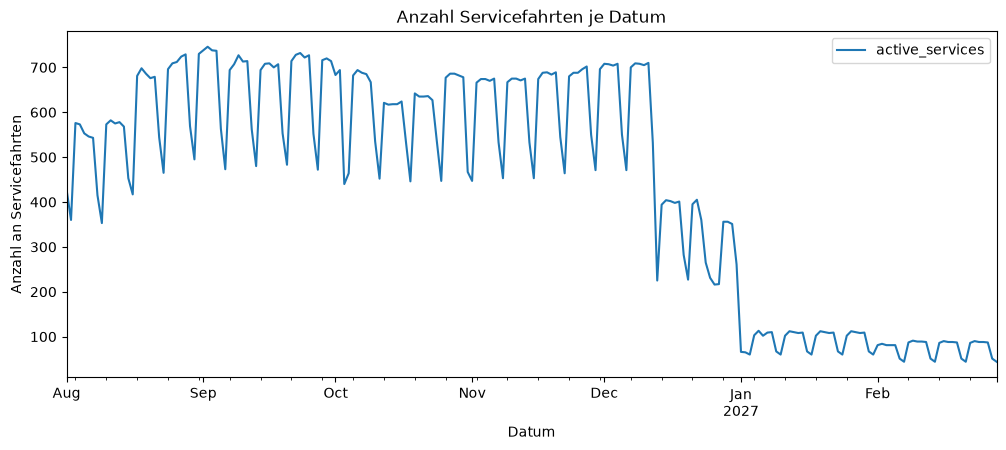

In [105]:
display(daily_services.head(15))
daily_services.plot(
    x="date",
    y="active_services",
    xlabel="Datum",
    ylabel="Anzahl an Servicefahrten",
    title="Anzahl Servicefahrten je Datum",
    figsize=(12,4.5),
)

In [106]:
#Trips mit Servicekalender connecten

trips_with_dates = service_calendar.merge(
    trips,
    on="service_id",
    how="inner"
)

print(len(trips_with_dates))
display(trips_with_dates.head())

1933045


,service_id,date,route_id,trip_id,trip_headsign,trip_short_name,direction_id,block_id,shape_id,wheelchair_accessible,bikes_allowed
0,7,2026-08-01,8047_3,37867325,"Hünfeld, Bahnhof",NaN,0,NaN,NaN,0,0
1,7,2026-08-01,8047_3,37867324,"Hünfeld, Bahnhof",NaN,0,NaN,NaN,0,0
2,7,2026-08-01,8047_3,37867323,"Hünfeld, Bahnhof",NaN,0,NaN,NaN,0,0
3,7,2026-08-01,8047_3,37867284,"Geisa, Point Alpha",NaN,1,NaN,NaN,0,0
4,7,2026-08-01,8047_3,37867283,"Geisa, Point Alpha",NaN,1,NaN,NaN,0,0


In [111]:
print("Anzahl eindeutiger Fahrten:", trips_with_dates["trip_id"].nunique())
print("Anzahl Betriebstage:", trips_with_dates["date"].nunique())
print("Durchschnittliche  Anzahl eindeztuger Fahrten pro Tag:",
      round(trips_with_dates["trip_id"].nunique() / trips_with_dates["date"].nunique(), 2))

print("Durchschnittliche  Fahrten pro Tag:",
      round(len(trips_with_dates) / trips_with_dates["date"].nunique(), 2))

Anzahl eindeutiger Fahrten: 22614
Anzahl Betriebstage: 212
Durchschnittliche  Anzahl eindeztuger Fahrten pro Tag: 106.67
Durchschnittliche  Fahrten pro Tag: 9118.14


In [113]:
daily_trips = (trips_with_dates.groupby("date").size().reset_index(name="planned_trips"))
display(daily_trips.head(20))

,date,planned_trips
0,2026-08-01,2877
1,2026-08-02,2295
2,2026-08-03,6771
3,2026-08-04,6817
4,2026-08-05,6727
5,2026-08-06,6718
6,2026-08-07,6702
7,2026-08-08,3001
8,2026-08-09,2387
9,2026-08-10,6880


<Axes: title={'center': 'Anzahl geplanter Fahrten je Datum'}, xlabel='Datum', ylabel='Geplante Fahrten'>

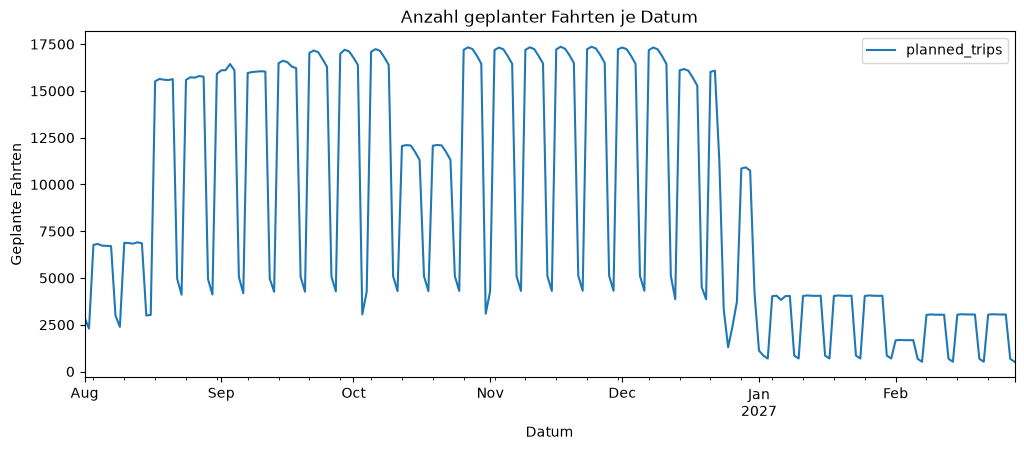

In [114]:
daily_trips.plot(
    x="date",
    y="planned_trips",
    xlabel="Datum",
    ylabel="Geplante Fahrten",
    title="Anzahl geplanter Fahrten je Datum",
    figsize=(12,4.5),
)